C:\Users\PRABHAHARN M\AppData\Local\Temp\ipykernel_12688\1682142697.py:37: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\PRABHAHARN M\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7125 - loss: 0.6227 - val_accuracy: 0.7350 - val_loss: 0.5671
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7225 - loss: 0.5715 - val_accuracy: 0.7350 - val_loss: 0.5431
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7225 - loss: 0.5542 - val_accuracy: 0.7350 - val_loss: 0.5202
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7275 - loss: 0.5300 - val_accuracy: 0.7550 - val_loss: 0.4983
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7287 - loss: 0.5008 - val_accuracy: 0.7550 - val_loss: 0.4696
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7638 - loss: 0.4741 - val_accuracy: 0.8050 - val_loss: 0.4454
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7837 - loss: 0.4480 - val_accuracy: 0.8700 - val_loss: 0.4262
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8388 - loss: 0.4267 - val_accuracy: 0.8500 - v

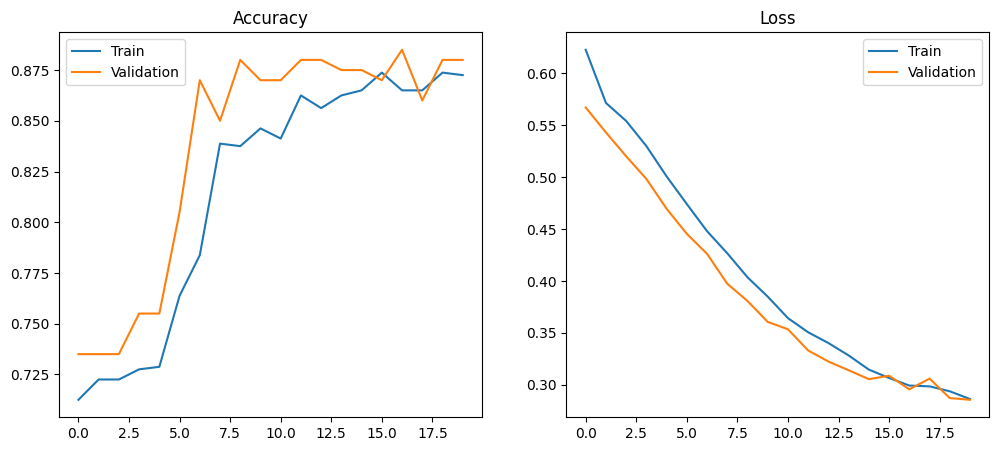

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout


# =====================
# Load Dataset
# =====================
df = pd.read_csv(r"D:\taskprogram\rain_forecasting.csv")

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# =====================
# Date Feature Engineering
# =====================
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Drop original Date column
df.drop('Date', axis=1, inplace=True)

# =====================
# Handle Missing Values
# =====================
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(method='ffill', inplace=True)

# =====================
# Encode Categorical Columns
# =====================
le = LabelEncoder()

df["Location"] = le.fit_transform(df["Location"])
df["RainToday"] = le.fit_transform(df["RainToday"])
df["RainTomorrow"] = le.fit_transform(df["RainTomorrow"])

# =====================
# Split Features & Target
# =====================
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

# =====================
# Scaling
# =====================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for GRU [samples, timesteps, features]
X_scaled = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# =====================
# GRU Model
# =====================
model = Sequential([
    GRU(64, input_shape=(1, X_train.shape[2])),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# =====================
# Training
# =====================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =====================
# Evaluation
# =====================
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# =====================
# Prediction on Test Data
# =====================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

labels = ["Yes" if i == 1 else "No" for i in y_pred.flatten()]
print("Sample Predictions:", labels[:10])

# =====================
# Future Date Prediction
# =====================
future_input = {
    "Location": 10,
    "MinTemp": 24.1,
    "MaxTemp": 34.6,
    "Humidity9am": 80,
    "Humidity3pm": 65,
    "Pressure9am": 1010,
    "Pressure3pm": 1007,
    "WindSpeed9am": 12,
    "WindSpeed3pm": 16,
    "RainToday": 1,
    "Year": 2026,
    "Month":3 ,
    "Day": 12,
    "DayOfWeek": 2
}

future_df = pd.DataFrame([future_input])
future_scaled = scaler.transform(future_df)
future_scaled = future_scaled.reshape(1, 1, future_scaled.shape[1])

prediction = model.predict(future_scaled)
prob = prediction[0][0] * 100

if prediction[0][0] > 0.5:
    print(f"🌧️ Rain expected ({prob:.2f}%)")
else:
    print(f"☀️ No rain expected ({100-prob:.2f}%)")

# =====================
# Accuracy & Loss Graphs
# =====================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()
